## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**DeepSeek-r1:31b** was tasked with generating a **couch** using the **SPOMSO** package. The model was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

I'll help you create a basic couch model using the SPOMSO library as described in the guide. I'll adapt the chair example to create a larger sofa with armrests and proper proportions.

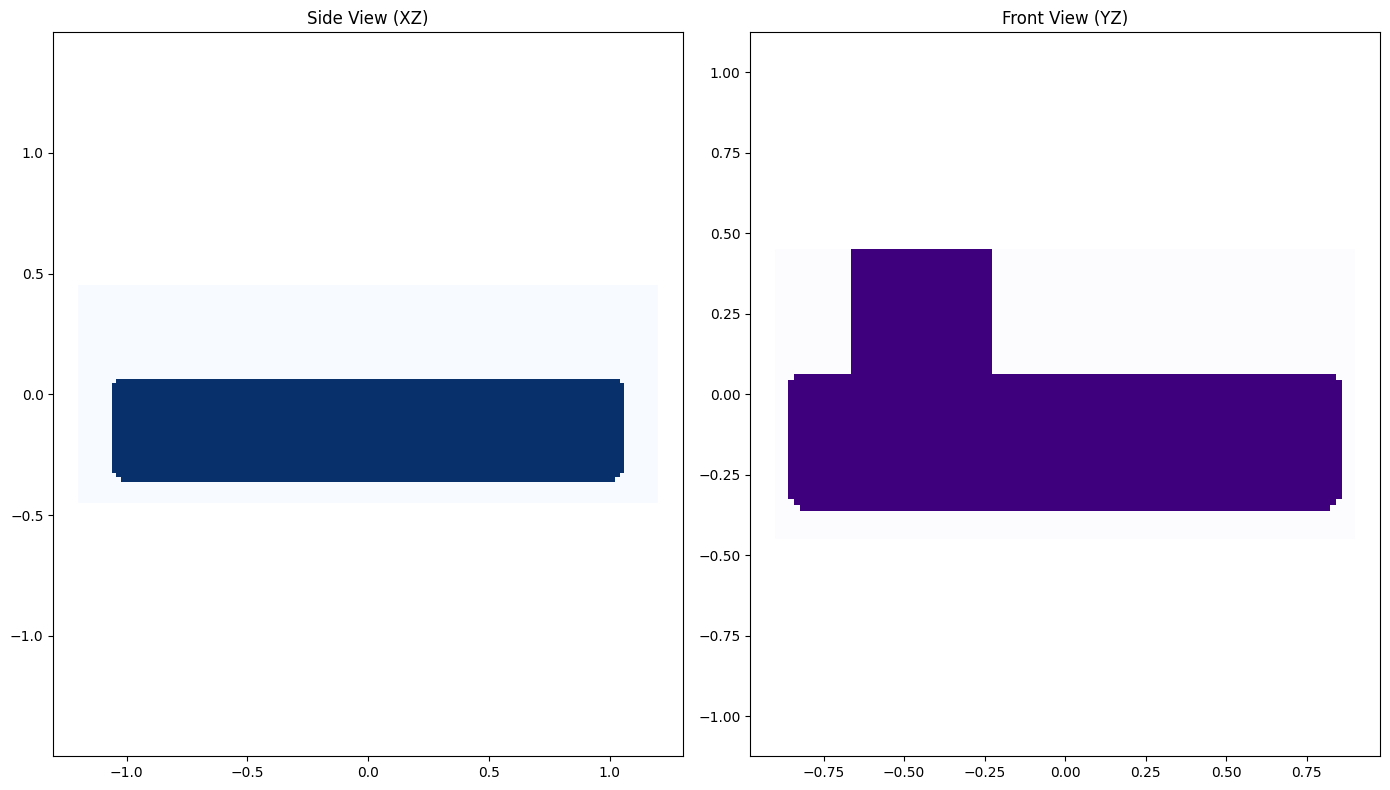

Point cloud saved: 102,529 points


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# Grid setup
CO_SIZE = (2.4, 1.8, 0.9)         # Larger dimensions for a couch
CO_RESOLUTION = (120, 90, 50)
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# Seat
seat = Box(2.0, 1.6, 0.3)        # Wider and longer than the chair
seat.rounding(0.07)              # Round edges for comfort
seat.move((0.0, 0.0, -0.15))     # Lower the seat slightly

# Backrest (taller than chair)
backrest = Box(2.0, 0.3, 0.8)    # Wider and taller backrest
backrest.rounding(0.07)
backrest.move((0.0, -0.45, 0.15))

# Armrests (add to both sides)
arm_left = Box(0.6, 0.25, 0.35)
arm_left.rounding(0.07)
arm_left.move((-0.8, 0.7, -0.1)) # Position on left side

arm_right = Box(0.6, 0.25, 0.35)
arm_right.rounding(0.07)
arm_right.move((0.8, 0.7, -0.1)) # Position on right side

# Legs (thicker and shorter than chair legs)
leg_positions = [(-0.9, 0.4, -0.2), (-0.9, -0.4, -0.2),
                 (0.9, 0.4, -0.2), (0.9, -0.4, -0.2)]
legs = []
for pos in leg_positions:
    leg = Cylinder(0.07, 0.3)
    leg.rounding(0.01)
    leg.move(pos)
    legs.append(leg)

# Combine all components
sofa = CombineGeometry("UNION").combine(
    seat, backrest, arm_left, arm_right, *legs
)

sdf = sofa.create(coor)

# Binary field and cross-sections
binary_3d = smarter_reshape(hard_binarization(sdf, 0), CO_RESOLUTION)

# Plot proportions
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Side view (XZ plane)
axes[0].imshow(binary_3d[:, co_res_new[1]//2, :].T,
               cmap="Blues", origin="lower",
               extent=(-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[0].set_title("Side View (XZ)")
axes[0].axis('equal')  # Maintain proportions

# Front view (YZ plane)
axes[1].imshow(binary_3d[co_res_new[0]//2, :, :].T,
               cmap="Purples", origin="lower",
               extent=(-CO_SIZE[1]/2, CO_SIZE[1]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2))
axes[1].set_title("Front View (YZ)")
axes[1].axis('equal')  # Maintain proportions

plt.tight_layout()
plt.show()

# Extract surface point cloud
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_pts = coor[:, np.abs(sdf) < dx * 1.5].T
np.save("sofa_surface.npy", surface_pts)
print(f"Point cloud saved: {surface_pts.shape[0]:,} points")

This code creates:
1. A wider and longer seat than the chair example
2. A taller backrest
3. Armrests on both sides
4. Thicker legs for better stability
5. All components are properly rounded to avoid sharp edges

The visualizations maintain true proportions by using `axis('equal')` in matplotlib, which ensures the aspect ratio is preserved.

You can adjust the dimensions, rounding radius, and positioning by modifying the parameters in the code. For example:
- Make it wider: Increase `CO_SIZE[0]` and seat dimensions
- Add more padding: Increase the rounding radius
- Make armrests taller or shorter: Adjust their dimensions

Let me know if you'd like to modify any specific aspect of the design!

**End response**

**Approximate time:** 5m 27s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=hard_binarization(sdf, 0),
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()